# Importing Libraries

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

In [3]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

In [4]:
# Set display options
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
matplotlib.rcParams['axes.labelsize'] = 14
matplotlib.rcParams['xtick.labelsize'] = 12
matplotlib.rcParams['ytick.labelsize'] = 12
matplotlib.rcParams['text.color'] = 'k'
plt.style.use('fivethirtyeight')

# Loading Dataset

In [5]:
# Behaviour datasets configuration
dataset_1 = "Mask Wearing.csv"
target_1 = "mask_wearing"

dataset_2 = "Hand Washing.csv"
target_2 = "wash_hands"

dataset_3 = "Avoid Crowded Areas.csv"
target_3 = "avoid_crowded_areas"

dataset_4 = "Self Isolation.csv"
target_4 = "willingness_self_isolate"

In [6]:
# Load and prepare data

def load_and_prepare_bsts_data(dataset, target):
    """
    Loads the final behaviour dataset and prepares daily-level
    time-series data for BSTS-style structural time-series modelling.

    The exogenous variable list is intentionally kept small because
    structural time-series models can become unstable when too many
    highly correlated predictors and lag variables are included.
    """

    df = pd.read_csv(dataset)

    df["date"] = pd.to_datetime(df["date"])

    df = df.sort_values("date")

    # Selected exogenous variables only
    # Lag variables, date features, and large sets of policy variables
    # are not included here to avoid instability and multicollinearity.
    exog_vars = [
        # Perception variables
        "covid_dangerous_for_me",
        "likely_to_get_covid",
        "trust_in_government_handling",
        "important_to_improve_health",
        "life_affected_by_covid",

        # Main policy variables
        "stringency_index",
        "mask_policy",
        "stay_home_requirement",
        "public_information_campaign",

        # Main epidemiological variables
        "new_cases_smoothed",
        "reproduction_rate",
        "hospital_patients",
        "people_fully_vaccinated_per_hundred",

        # Interaction variables
        "policy_x_cases",
        "risk_x_trust"
    ]

    # Keep only columns available in the selected dataset
    exog_vars = [
        col for col in exog_vars
        if col in df.columns
    ]

    # Aggregate survey-level data to daily time-series data
    daily_df = (
        df.groupby("date")[[target] + exog_vars]
        .mean()
        .reset_index()
    )

    daily_df = daily_df.set_index("date")

    daily_df = daily_df.asfreq("D")

    daily_df = daily_df.ffill().bfill()

    # Remove constant exogenous variables because they do not help the model
    constant_cols = [
        col for col in exog_vars
        if daily_df[col].nunique() <= 1
    ]

    if len(constant_cols) > 0:
        daily_df = daily_df.drop(columns=constant_cols)
        exog_vars = [col for col in exog_vars if col not in constant_cols]
        print("Constant exogenous variables removed:", constant_cols)

    print("Dataset loaded successfully")
    print("Daily BSTS dataset shape:", daily_df.shape)
    print("Target variable:", target)
    print("Number of exogenous variables:", len(exog_vars))
    print("Exogenous variables used:", exog_vars)

    return daily_df, exog_vars


# BSTS Model

In [7]:
# Check stationarity
def check_stationarity(series):
    """
    Performs Augmented Dickey-Fuller test on the target series.
    """

    result = adfuller(series.dropna())

    print("\nStationarity Check")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    if result[1] < 0.05:
        print("Result: Series is stationary")
    else:
        print("Result: Series is not stationary")

    return result[1]

In [8]:
# Train-test split and scaling

def split_and_scale_bsts_data(daily_df, target, exog_vars, train_ratio=0.80):
    """
    Splits the data chronologically into training and testing sets.
    Exogenous variables are scaled using training data only.

    A full scaled exogenous matrix is also returned because the
    structural model is fitted on the full observed series for
    one-step-ahead test-period prediction, not future forecasting.
    """

    train_size = int(len(daily_df) * train_ratio)

    train_df = daily_df.iloc[:train_size]
    test_df = daily_df.iloc[train_size:]

    y_full = daily_df[target]
    y_train = train_df[target]
    y_test = test_df[target]

    X_full = daily_df[exog_vars]
    X_train = train_df[exog_vars]
    X_test = test_df[exog_vars]

    scaler = StandardScaler()

    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train),
        columns=exog_vars,
        index=X_train.index
    )

    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test),
        columns=exog_vars,
        index=X_test.index
    )

    X_full_scaled = pd.DataFrame(
        scaler.transform(X_full),
        columns=exog_vars,
        index=X_full.index
    )

    print("\nTrain-Test Split")
    print("Training target shape:", y_train.shape)
    print("Testing target shape:", y_test.shape)
    print("Training exogenous shape:", X_train_scaled.shape)
    print("Testing exogenous shape:", X_test_scaled.shape)

    return y_full, y_train, y_test, X_full_scaled, X_train_scaled, X_test_scaled


In [9]:
# Train BSTS-style structural time-series model

def train_bsts_model(y_full, X_full):
    """
    Trains a stable BSTS-style structural time-series model using
    a local level component, weekly seasonality, and a small set of
    exogenous variables.

    This uses statsmodels UnobservedComponents as a structural
    time-series approximation. A local level is used instead of a
    local linear trend because it is more stable for this dataset.
    """

    model = sm.tsa.UnobservedComponents(
        endog=y_full,
        exog=X_full,
        level="local level",
        seasonal=7
    )

    result = model.fit(disp=False)

    print("\nBSTS-style Structural Model Summary")
    print(result.summary())

    return result


In [10]:
# Test-period prediction

def predict_bsts_test_period(model_result, y_test):
    """
    Generates one-step-ahead predictions for the observed test period.
    This does not forecast future unseen dates.
    """

    prediction_object = model_result.get_prediction(
        start=y_test.index[0],
        end=y_test.index[-1],
        dynamic=False
    )

    predictions = prediction_object.predicted_mean

    predictions = pd.Series(
        predictions,
        index=y_test.index
    )

    return predictions


In [11]:
# Evaluate model
def evaluate_bsts_model(y_test, predictions):
    """
    Calculates model accuracy metrics.
    R2 is not included.
    """

    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions)

    results = pd.DataFrame({
        "Model": ["BSTS"],
        "MSE": [mse],
        "RMSE": [rmse],
        "MAE": [mae],
        "MAPE": [mape]
    })

    print("\nBSTS Accuracy Results")
    print(results)

    return results

In [12]:
# Plot results
def plot_bsts_results(y_train, y_test, predictions, target):
    """
    Creates readable plots for:
    1. Training, actual test, and predicted values
    2. Actual vs predicted values
    3. Residuals
    """

    target_label_map = {
        "mask_wearing": "Mask Wearing",
        "wash_hands": "Hand Washing",
        "avoid_crowded_areas": "Avoid Crowded Areas",
        "willingness_self_isolate": "Self Isolation"
    }

    target_label = target_label_map.get(
        target,
        target.replace("_", " ").title()
    )

    plt.figure(figsize=(14, 7))

    plt.plot(
        y_train.index,
        y_train,
        label="Training Data",
        color="#1f77b4",
        linewidth=2
    )

    plt.plot(
        y_test.index,
        y_test,
        label="Actual Test Data",
        color="#ff7f0e",
        linewidth=2
    )

    plt.plot(
        predictions.index,
        predictions,
        label="BSTS Predicted Values",
        color="#d62728",
        linewidth=2.5
    )

    plt.xlabel("Date", fontsize=14)
    plt.ylabel(target_label, fontsize=14)

    plt.legend(fontsize=12)

    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.show()

    plt.figure(figsize=(7, 7))

    plt.scatter(
        y_test,
        predictions,
        color="#1f77b4",
        alpha=0.7,
        edgecolor="black"
    )

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="#d62728",
        linestyle="--",
        linewidth=2
    )
    plt.xlabel("Actual Values", fontsize=13)
    plt.ylabel("Predicted Values", fontsize=13)

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    residuals = y_test - predictions

    plt.figure(figsize=(14, 5))

    plt.plot(
        residuals.index,
        residuals,
        color="#1f77b4",
        linewidth=2
    )

    plt.axhline(
        0,
        color="#d62728",
        linestyle="--",
        linewidth=2
    )
    plt.xlabel("Date", fontsize=13)
    plt.ylabel("Residual", fontsize=13)

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [13]:
# BSTS pipeline

def run_bsts_pipeline(dataset, target):
    """
    Runs the complete BSTS-style structural time-series modelling pipeline.
    """

    daily_df, exog_vars = load_and_prepare_bsts_data(
        dataset,
        target
    )

    check_stationarity(
        daily_df[target]
    )

    y_full, y_train, y_test, X_full, X_train, X_test = split_and_scale_bsts_data(
        daily_df,
        target,
        exog_vars
    )

    bsts_result = train_bsts_model(
        y_full,
        X_full
    )

    predictions = predict_bsts_test_period(
        bsts_result,
        y_test
    )

    accuracy_results = evaluate_bsts_model(
        y_test,
        predictions
    )

    plot_bsts_results(
        y_train,
        y_test,
        predictions,
        target
    )

    return bsts_result, accuracy_results


# Results

Constant exogenous variables removed: ['public_information_campaign']
Dataset loaded successfully
Daily BSTS dataset shape: (727, 15)
Target variable: mask_wearing
Number of exogenous variables: 14
Exogenous variables used: ['covid_dangerous_for_me', 'likely_to_get_covid', 'trust_in_government_handling', 'important_to_improve_health', 'life_affected_by_covid', 'stringency_index', 'mask_policy', 'stay_home_requirement', 'new_cases_smoothed', 'reproduction_rate', 'hospital_patients', 'people_fully_vaccinated_per_hundred', 'policy_x_cases', 'risk_x_trust']

Stationarity Check
ADF Statistic: -4.8572007360904905
p-value: 4.2219253269175804e-05
Result: Series is stationary

Train-Test Split
Training target shape: (581,)
Testing target shape: (146,)
Training exogenous shape: (581, 14)
Testing exogenous shape: (146, 14)

BSTS-style Structural Model Summary
                           Unobserved Components Results                            
Dep. Variable:                 mask_wearing   No. Obse

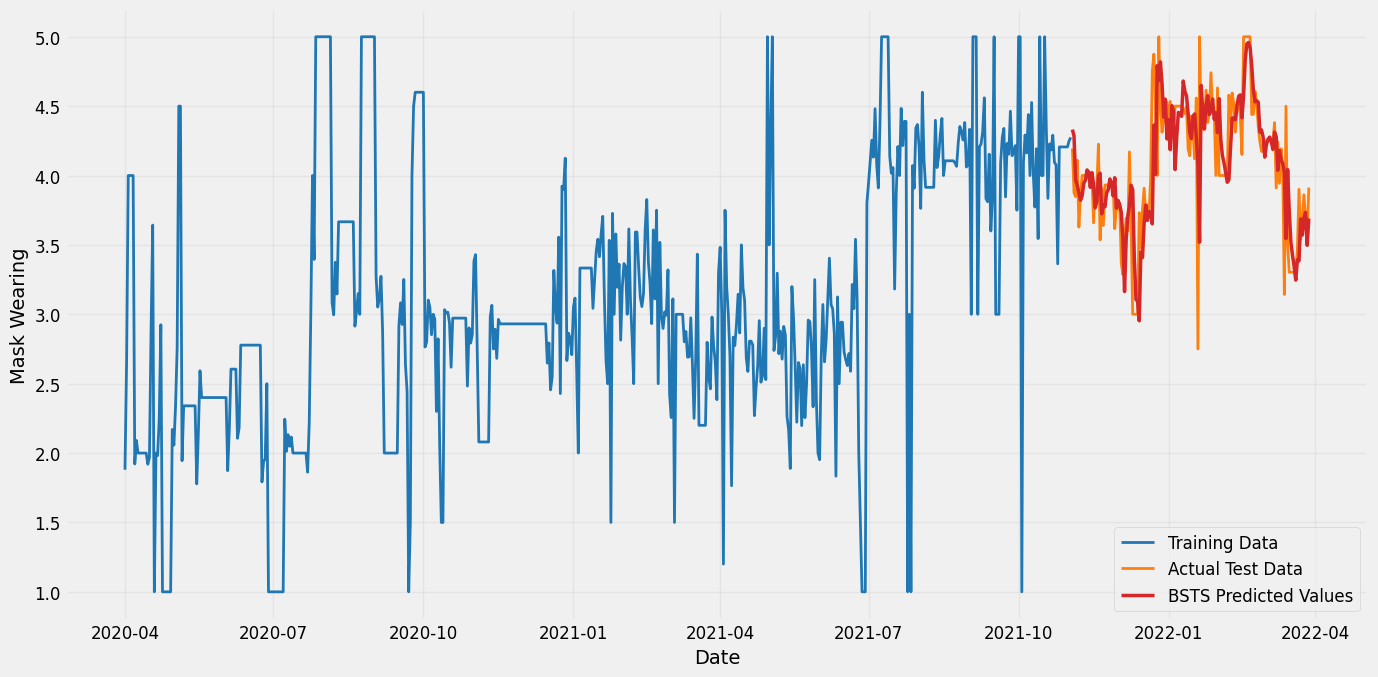

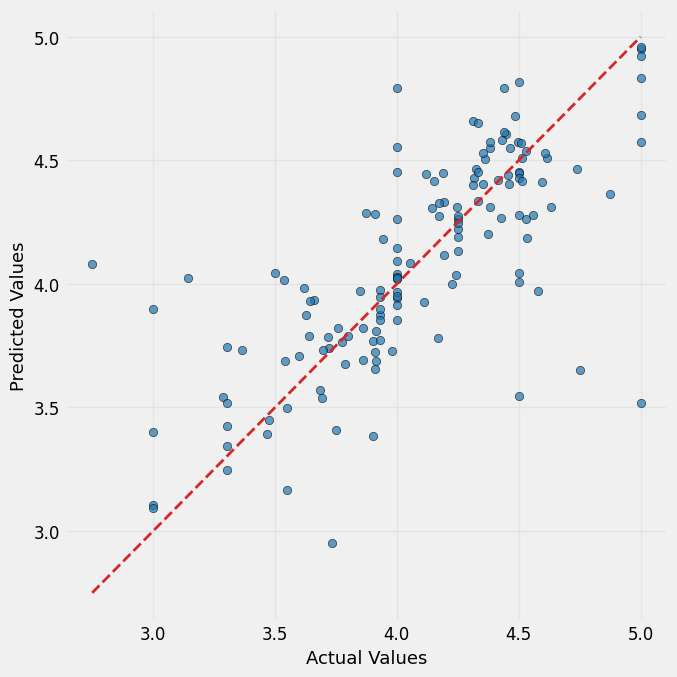

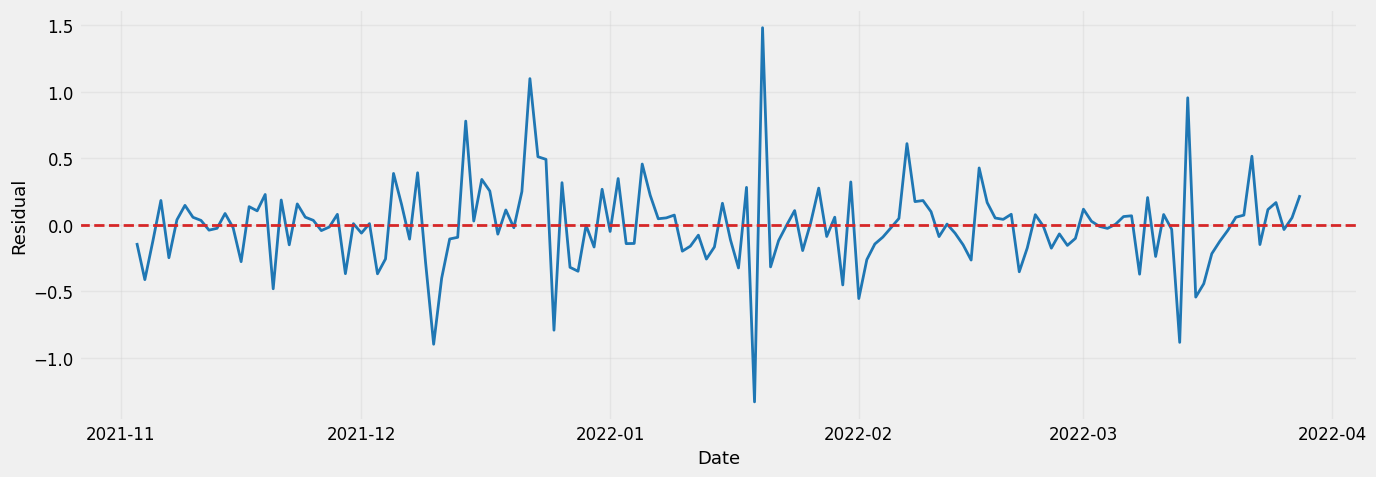

In [14]:
# Run model for mask wearing
mask_model, mask_accuracy = run_bsts_pipeline(
    dataset_1,
    target_1
)

Constant exogenous variables removed: ['public_information_campaign']
Dataset loaded successfully
Daily BSTS dataset shape: (715, 15)
Target variable: wash_hands
Number of exogenous variables: 14
Exogenous variables used: ['covid_dangerous_for_me', 'likely_to_get_covid', 'trust_in_government_handling', 'important_to_improve_health', 'life_affected_by_covid', 'stringency_index', 'mask_policy', 'stay_home_requirement', 'new_cases_smoothed', 'reproduction_rate', 'hospital_patients', 'people_fully_vaccinated_per_hundred', 'policy_x_cases', 'risk_x_trust']

Stationarity Check
ADF Statistic: -9.293927448932413
p-value: 1.1597651425243651e-15
Result: Series is stationary

Train-Test Split
Training target shape: (572,)
Testing target shape: (143,)
Training exogenous shape: (572, 14)
Testing exogenous shape: (143, 14)

BSTS-style Structural Model Summary
                           Unobserved Components Results                            
Dep. Variable:                   wash_hands   No. Observa

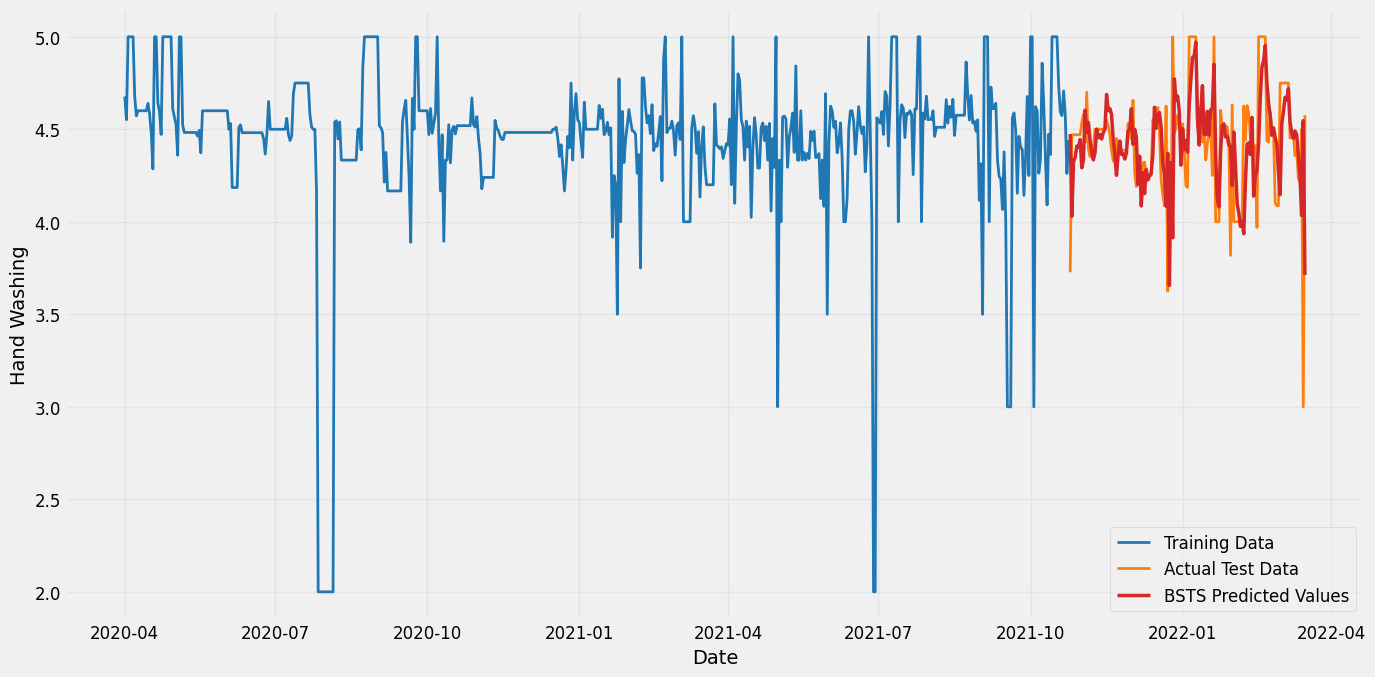

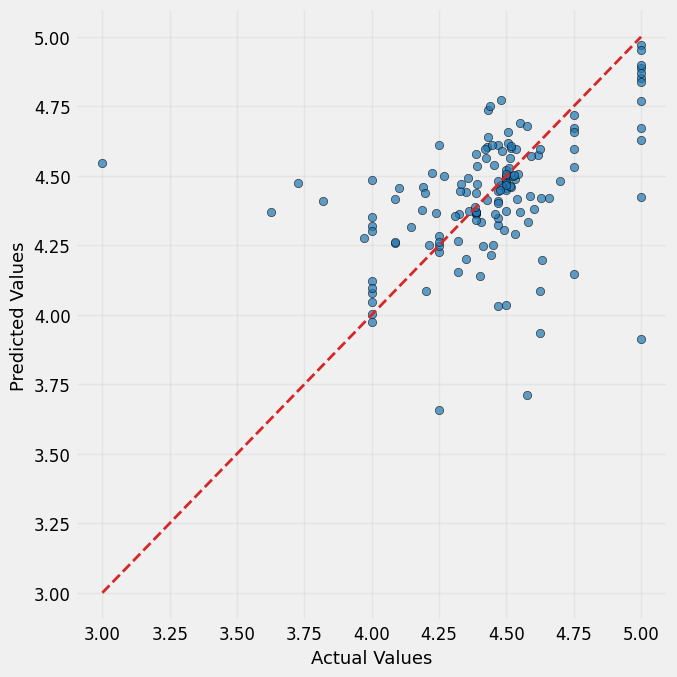

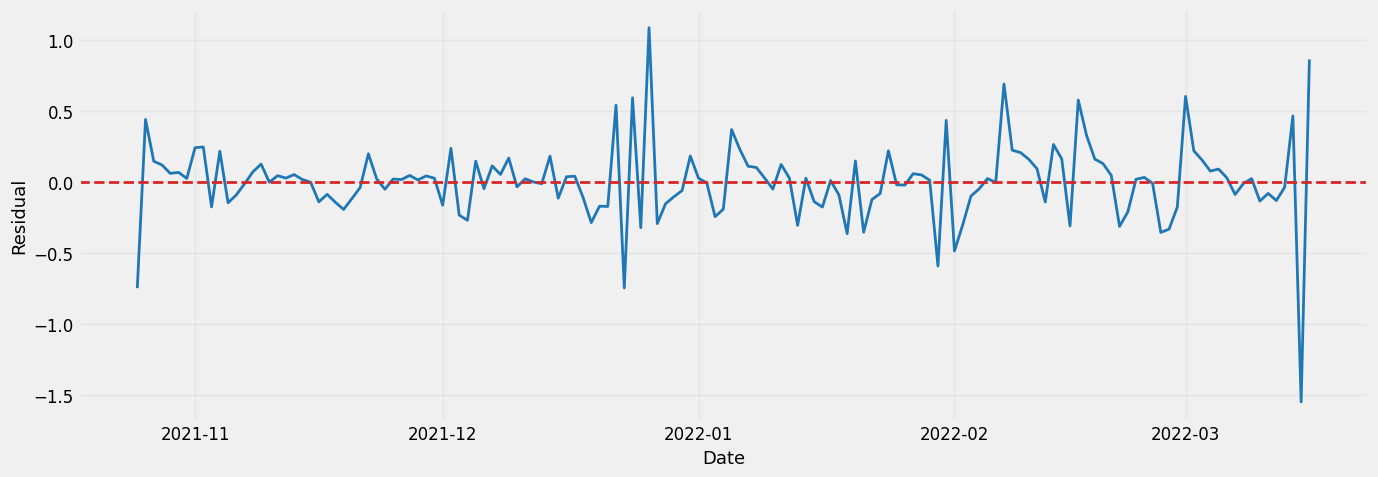

In [15]:
# Run model for hand washing
handwashing_model, handwashing_accuracy = run_bsts_pipeline(
    dataset_2,
    target_2
)

Constant exogenous variables removed: ['public_information_campaign']
Dataset loaded successfully
Daily BSTS dataset shape: (727, 15)
Target variable: avoid_crowded_areas
Number of exogenous variables: 14
Exogenous variables used: ['covid_dangerous_for_me', 'likely_to_get_covid', 'trust_in_government_handling', 'important_to_improve_health', 'life_affected_by_covid', 'stringency_index', 'mask_policy', 'stay_home_requirement', 'new_cases_smoothed', 'reproduction_rate', 'hospital_patients', 'people_fully_vaccinated_per_hundred', 'policy_x_cases', 'risk_x_trust']

Stationarity Check
ADF Statistic: -7.2020615606250455
p-value: 2.351458071674493e-10
Result: Series is stationary

Train-Test Split
Training target shape: (581,)
Testing target shape: (146,)
Training exogenous shape: (581, 14)
Testing exogenous shape: (146, 14)

BSTS-style Structural Model Summary
                           Unobserved Components Results                            
Dep. Variable:          avoid_crowded_areas   No

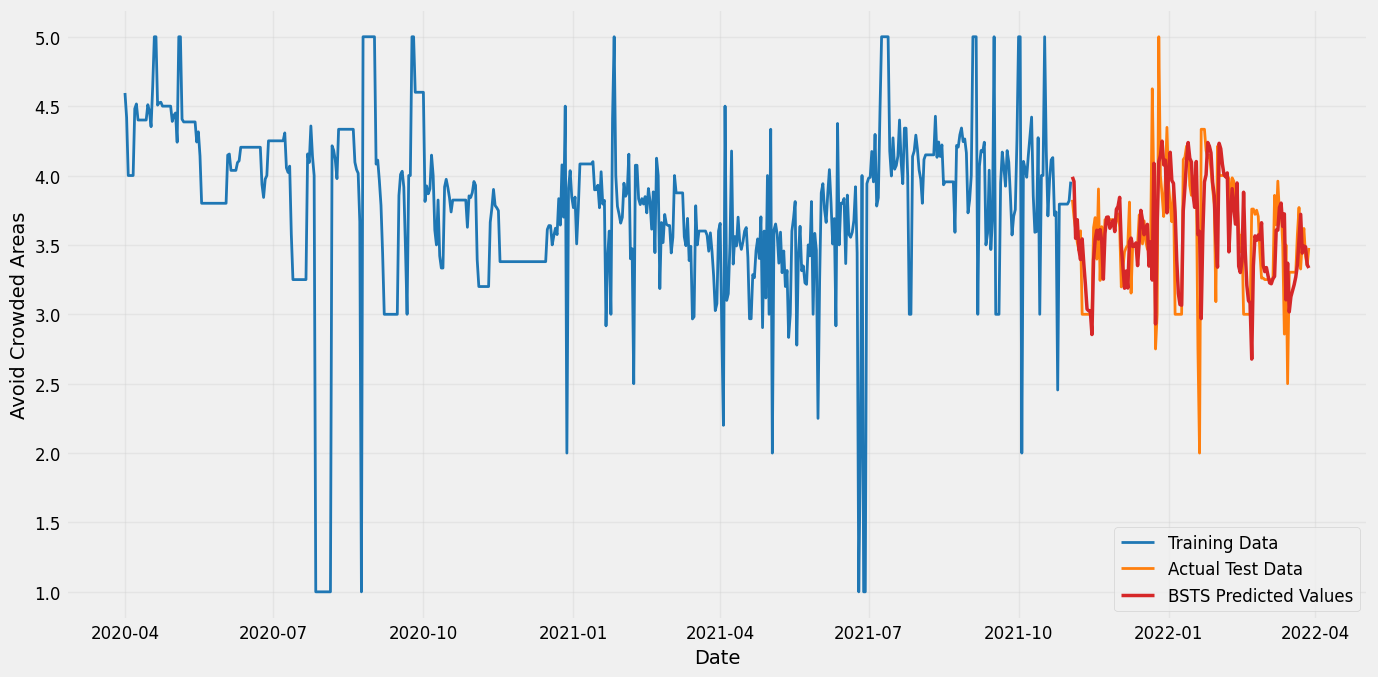

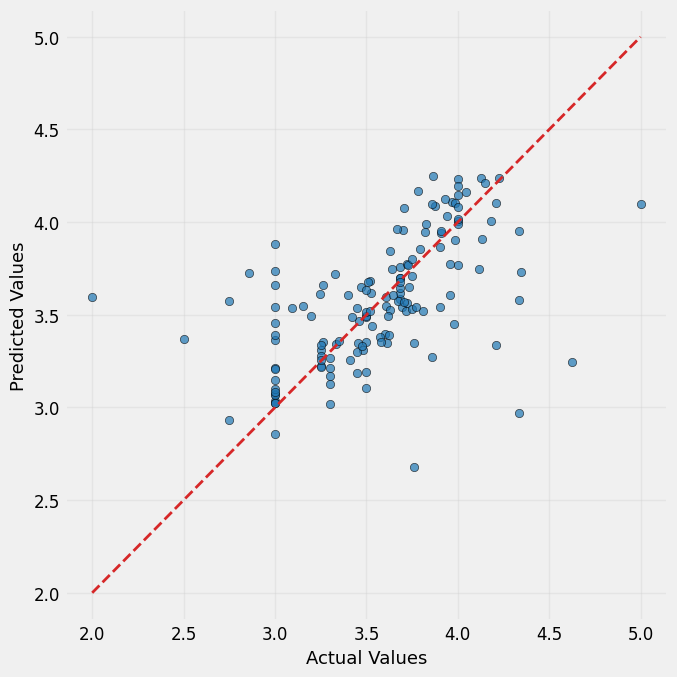

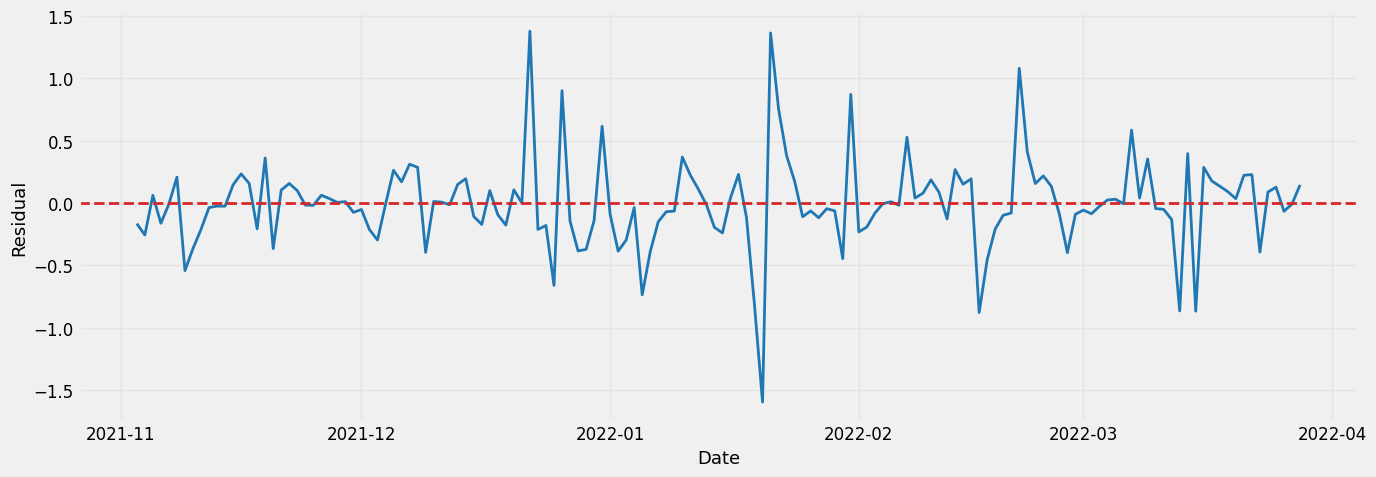

In [16]:
# Run model for Avoid Crowded Areas
crowded_model, crowded_accuracy = run_bsts_pipeline(
    dataset_3,
    target_3
)

Constant exogenous variables removed: ['public_information_campaign']
Dataset loaded successfully
Daily BSTS dataset shape: (727, 15)
Target variable: willingness_self_isolate
Number of exogenous variables: 14
Exogenous variables used: ['covid_dangerous_for_me', 'likely_to_get_covid', 'trust_in_government_handling', 'important_to_improve_health', 'life_affected_by_covid', 'stringency_index', 'mask_policy', 'stay_home_requirement', 'new_cases_smoothed', 'reproduction_rate', 'hospital_patients', 'people_fully_vaccinated_per_hundred', 'policy_x_cases', 'risk_x_trust']

Stationarity Check
ADF Statistic: -6.449163603615237
p-value: 1.5388218162257924e-08
Result: Series is stationary

Train-Test Split
Training target shape: (581,)
Testing target shape: (146,)
Training exogenous shape: (581, 14)
Testing exogenous shape: (146, 14)

BSTS-style Structural Model Summary
                           Unobserved Components Results                            
Dep. Variable:     willingness_self_isolate

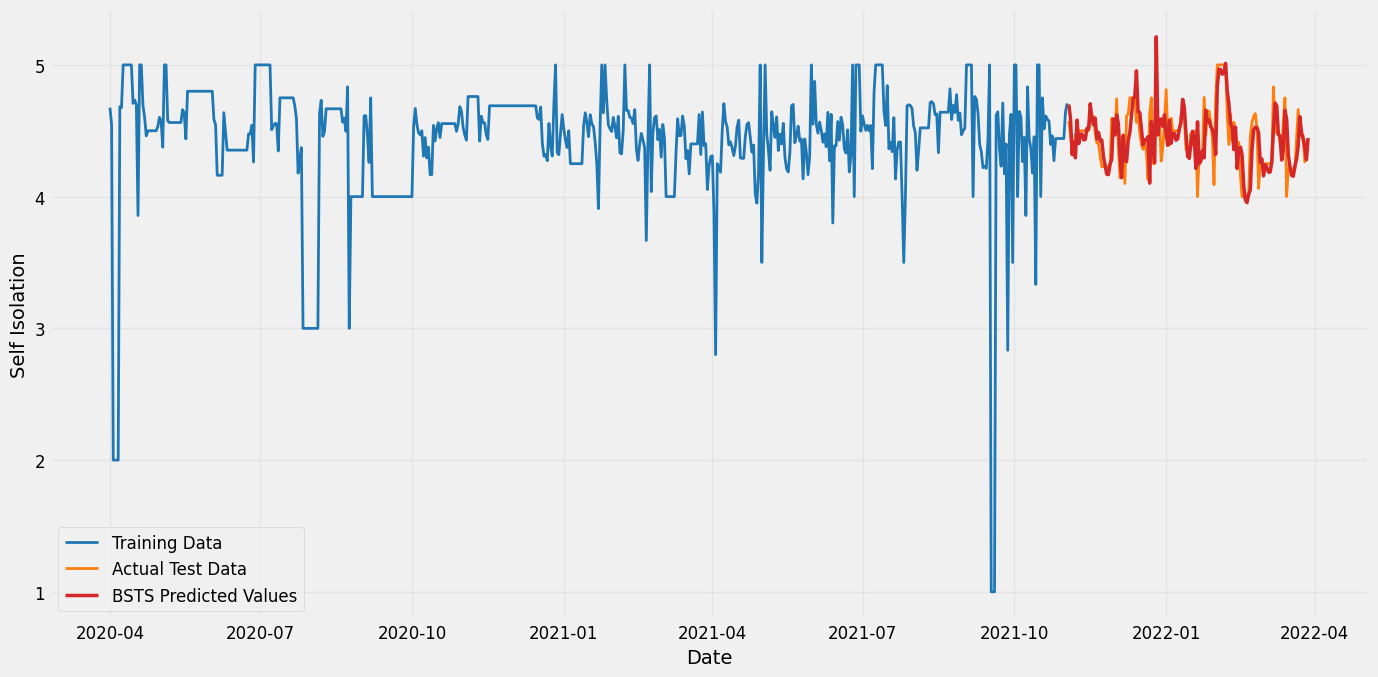

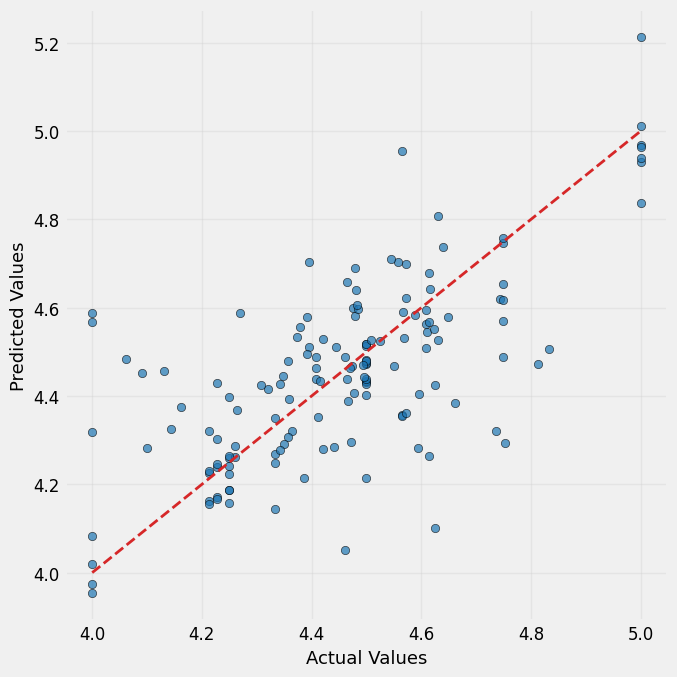

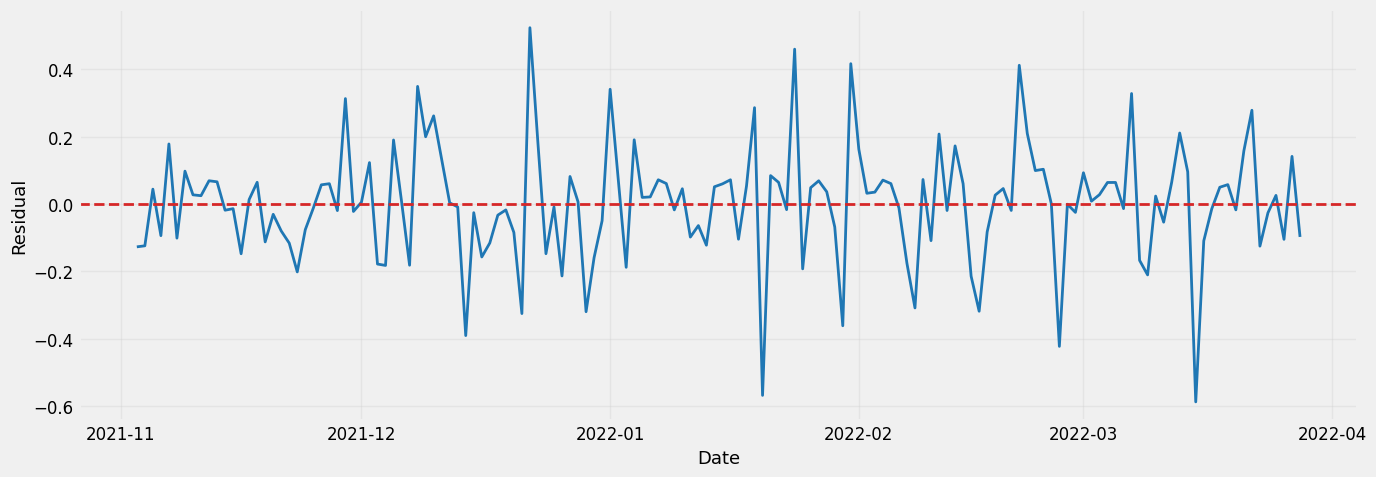

In [17]:
# Run model for self isolation
self_model, self_accuracy = run_bsts_pipeline(
    dataset_4,
    target_4
)

In [18]:
# Combine BSTS results for all 4 outcomes
bsts_results_table = pd.concat(
    [
        mask_accuracy,
        handwashing_accuracy,
        crowded_accuracy,
        self_accuracy
    ],
    ignore_index=True
)

bsts_results_table.insert(
    0,
    "Outcome Variable",
    [
        "Mask Wearing",
        "Hand Washing",
        "Avoid Crowded Areas",
        "Self Isolation"
    ]
)

bsts_results_table


,Outcome Variable,Model,MSE,RMSE,MAE,MAPE
0,Mask Wearing,BSTS,0.108457,0.329328,0.219527,0.055554
1,Hand Washing,BSTS,0.081065,0.284719,0.182629,0.042696
2,Avoid Crowded Areas,BSTS,0.135387,0.367950,0.239020,0.069766
3,Self Isolation,BSTS,0.029967,0.173109,0.123170,0.027787


Constant exogenous variables removed: ['public_information_campaign']
Dataset loaded successfully
Daily BSTS dataset shape: (727, 15)
Target variable: mask_wearing
Number of exogenous variables: 14
Exogenous variables used: ['covid_dangerous_for_me', 'likely_to_get_covid', 'trust_in_government_handling', 'important_to_improve_health', 'life_affected_by_covid', 'stringency_index', 'mask_policy', 'stay_home_requirement', 'new_cases_smoothed', 'reproduction_rate', 'hospital_patients', 'people_fully_vaccinated_per_hundred', 'policy_x_cases', 'risk_x_trust']


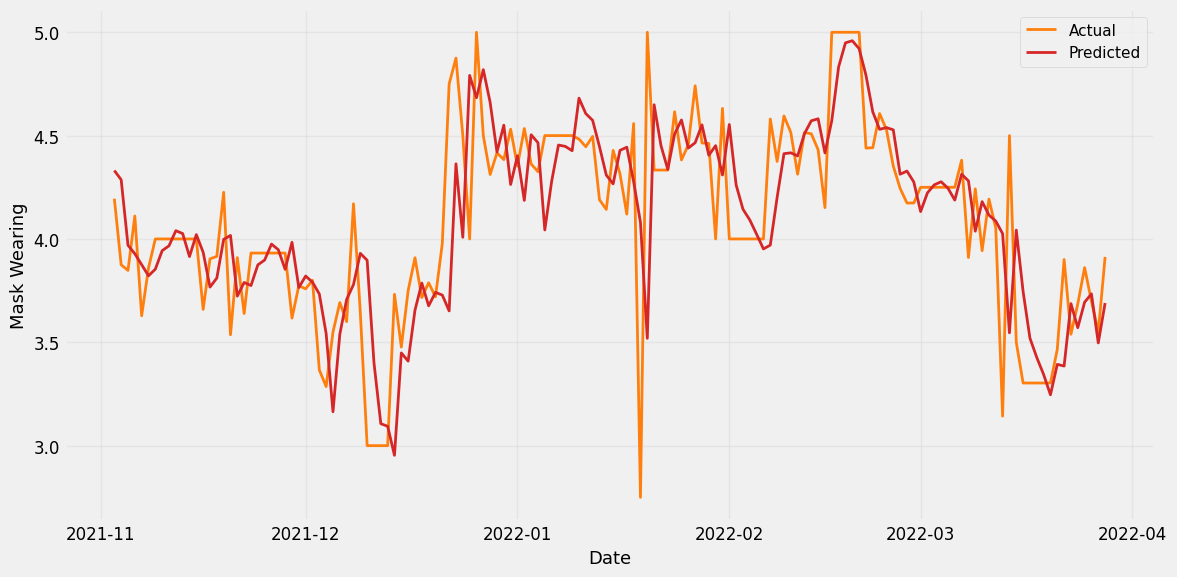

Constant exogenous variables removed: ['public_information_campaign']
Dataset loaded successfully
Daily BSTS dataset shape: (715, 15)
Target variable: wash_hands
Number of exogenous variables: 14
Exogenous variables used: ['covid_dangerous_for_me', 'likely_to_get_covid', 'trust_in_government_handling', 'important_to_improve_health', 'life_affected_by_covid', 'stringency_index', 'mask_policy', 'stay_home_requirement', 'new_cases_smoothed', 'reproduction_rate', 'hospital_patients', 'people_fully_vaccinated_per_hundred', 'policy_x_cases', 'risk_x_trust']


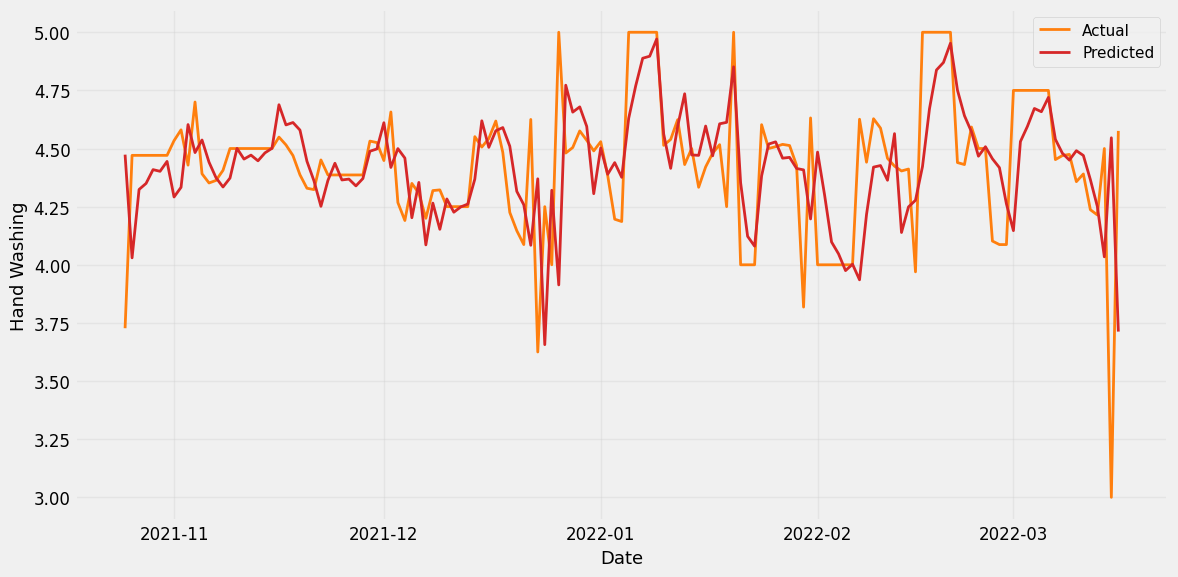

Constant exogenous variables removed: ['public_information_campaign']
Dataset loaded successfully
Daily BSTS dataset shape: (727, 15)
Target variable: avoid_crowded_areas
Number of exogenous variables: 14
Exogenous variables used: ['covid_dangerous_for_me', 'likely_to_get_covid', 'trust_in_government_handling', 'important_to_improve_health', 'life_affected_by_covid', 'stringency_index', 'mask_policy', 'stay_home_requirement', 'new_cases_smoothed', 'reproduction_rate', 'hospital_patients', 'people_fully_vaccinated_per_hundred', 'policy_x_cases', 'risk_x_trust']


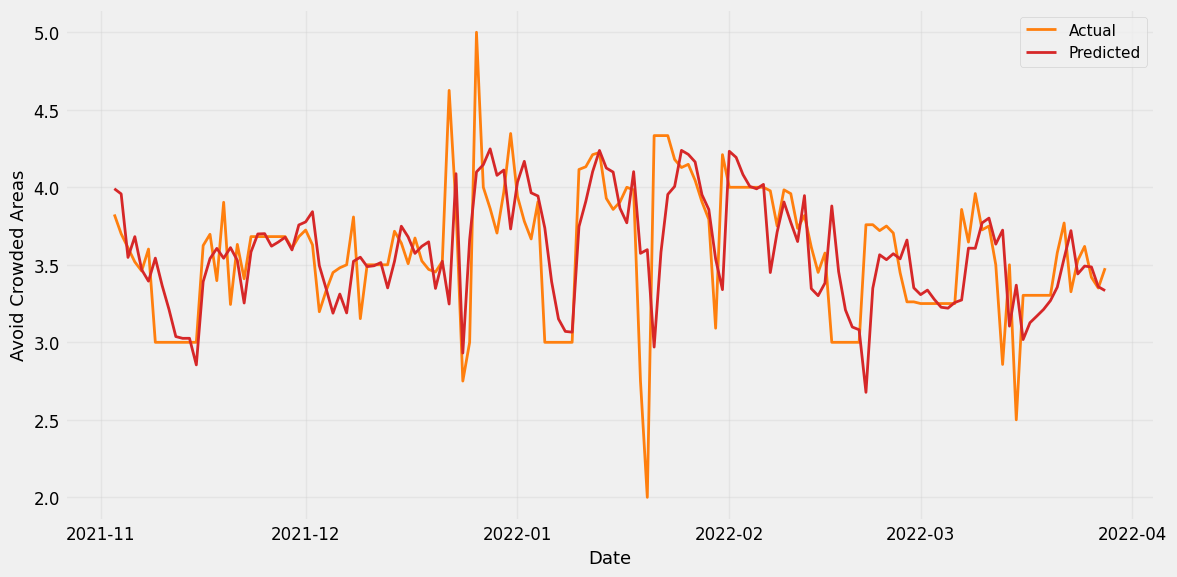

Constant exogenous variables removed: ['public_information_campaign']
Dataset loaded successfully
Daily BSTS dataset shape: (727, 15)
Target variable: willingness_self_isolate
Number of exogenous variables: 14
Exogenous variables used: ['covid_dangerous_for_me', 'likely_to_get_covid', 'trust_in_government_handling', 'important_to_improve_health', 'life_affected_by_covid', 'stringency_index', 'mask_policy', 'stay_home_requirement', 'new_cases_smoothed', 'reproduction_rate', 'hospital_patients', 'people_fully_vaccinated_per_hundred', 'policy_x_cases', 'risk_x_trust']


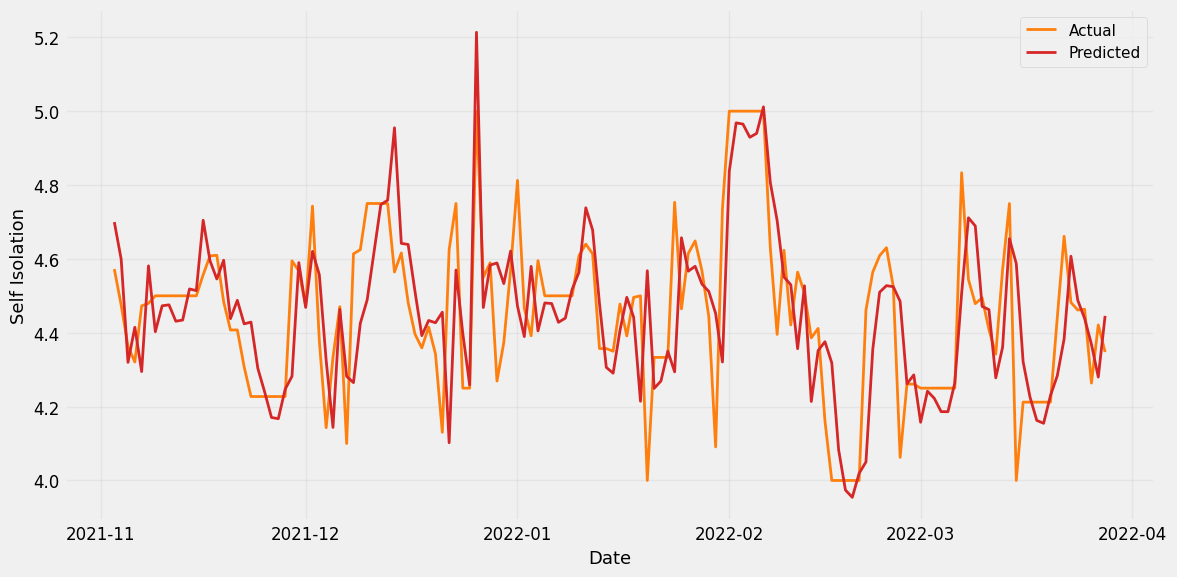

In [ ]:
# BSTS Testing-Period Plots
# Actual Test Data vs BSTS Predicted Values
bsts_plot_config = [
    {
        "dataset": dataset_1,
        "target": target_1,
        "model": mask_model
    },
    {
        "dataset": dataset_2,
        "target": target_2,
        "model": handwashing_model
    },
    {
        "dataset": dataset_3,
        "target": target_3,
        "model": crowded_model
    },
    {
        "dataset": dataset_4,
        "target": target_4,
        "model": self_model
    }
]

target_label_map = {
    "mask_wearing": "Mask Wearing",
    "wash_hands": "Hand Washing",
    "avoid_crowded_areas": "Avoid Crowded Areas",
    "willingness_self_isolate": "Self Isolation"
}

for config in bsts_plot_config:

    # Prepare the same daily data used in the BSTS model
    daily_df, exog_vars = load_and_prepare_bsts_data(
        config["dataset"],
        config["target"]
    )

    # Recreate the same chronological 80:20 train-test split
    train_size = int(len(daily_df) * 0.80)

    y_test = daily_df[config["target"]].iloc[train_size:]

    # Generate predictions for the testing period
    predictions = predict_bsts_test_period(
        config["model"],
        y_test
    )

    # Align predictions with the test dates
    predictions = predictions.reindex(y_test.index)

    # Plot only the zoomed testing region
    plt.figure(figsize=(12, 6))

    plt.plot(
        y_test.index,
        y_test.values,
        label="Actual",
        color="#ff7f0e",
        linewidth=2
    )

    plt.plot(
        predictions.index,
        predictions.values,
        label="Predicted",
        color="#d62728",
        linewidth=2
    )

    plt.xlabel("Date", fontsize=13)

    plt.ylabel(
        target_label_map.get(
            config["target"],
            config["target"].replace("_", " ").title()
        ),
        fontsize=13
    )

    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)

    # No title
    plt.tight_layout()
    plt.show()